In [12]:
import pandas as pd
import numpy as np

print("Python environment is working!")
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)

Python environment is working!
Pandas version: 3.0.6
NumPy version: 2.5.3


Log-transform pipeline (all cities)

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEED = 42
PRICE_CAP = 500

NUM = ["accommodates", "bedrooms", "beds", "bathrooms",
       "number_of_reviews", "number_of_reviews_ltm", "reviews_per_month",
       "availability_365", "minimum_nights", "review_scores_rating",
       "latitude", "longitude"]
CAT = ["room_type", "property_type", "neighbourhood_cleansed"]


def prepare_city(raw, price_cap=PRICE_CAP):
    """Clean price, drop missing/extreme prices, add log target."""
    df = raw[["price"] + NUM + CAT].copy()
    df["price"] = pd.to_numeric(
        df["price"].astype(str).str.replace(r"[^0-9.]", "", regex=True),
        errors="coerce")
    for c in NUM:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    n0 = len(df)
    df = df.dropna(subset=["price"])
    df = df[(df["price"] > 0) & (df["price"] <= price_cap)]
    df["log_price"] = np.log1p(df["price"])
    print(f"rows: {n0} -> {len(df)} after dropping missing price and capping at {price_cap}")
    return df.reset_index(drop=True)


def split_712(df):
    """7:2:1 train/val/test, as in the paper."""
    trainval, test = train_test_split(df, test_size=0.10, random_state=SEED)
    train, val = train_test_split(trainval, test_size=2 / 9, random_state=SEED)
    return train, val, test


def build_preprocessor():
    num = Pipeline([("imp", SimpleImputer(strategy="median", add_indicator=True)),
                    ("sc", StandardScaler())])
    cat = Pipeline([("imp", SimpleImputer(strategy="constant", fill_value="missing")),
                    ("oh", OneHotEncoder(handle_unknown="ignore", min_frequency=20))])
    return ColumnTransformer([("num", num, NUM), ("cat", cat, CAT)])


def get_models():
    return {
        "Ridge": Ridge(alpha=1.0),
        "KNN": KNeighborsRegressor(n_neighbors=10, n_jobs=-1),
        "RandomForest": RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=SEED),
        "XGBoost": XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05,
                                subsample=0.8, colsample_bytree=0.8,
                                random_state=SEED, n_jobs=-1),
    }


def evaluate(pipe, df):
    pred_log = pipe.predict(df[NUM + CAT])
    pred_usd = np.expm1(pred_log)
    return {"R2_log": r2_score(df["log_price"], pred_log),
            "RMSE_log": np.sqrt(mean_squared_error(df["log_price"], pred_log)),
            "MAE_usd": mean_absolute_error(df["price"], pred_usd),
            "RMSE_usd": np.sqrt(mean_squared_error(df["price"], pred_usd))}


def run_city(city, raw):
    print(f"--- {city} ---")
    df = prepare_city(raw)
    train, val, test = split_712(df)
    print(f"train/val/test = {len(train)}/{len(val)}/{len(test)}")
    rows = []
    for name, model in get_models().items():
        pipe = Pipeline([("prep", build_preprocessor()), ("model", model)])
        pipe.fit(train[NUM + CAT], train["log_price"])
        for split_name, part in [("train", train), ("val", val), ("test", test)]:
            rows.append({"city": city, "model": name, "split": split_name, **evaluate(pipe, part)})
    return pd.DataFrame(rows), (train, val, test)

In [14]:
import pandas as pd

nyc = pd.read_csv("../data/NYC/listings.csv.gz")
paris = pd.read_csv("../data/Paris/listings (1).csv.gz")
berlin = pd.read_csv("../data/berlin/listings (2).csv.gz")

print("NYC:", nyc.shape, "| Paris:", paris.shape, "| Berlin:", berlin.shape)

NYC: (30259, 90) | Paris: (77679, 90) | Berlin: (12776, 90)


rows: 77679 -> 42089 after dropping missing price and capping at 500


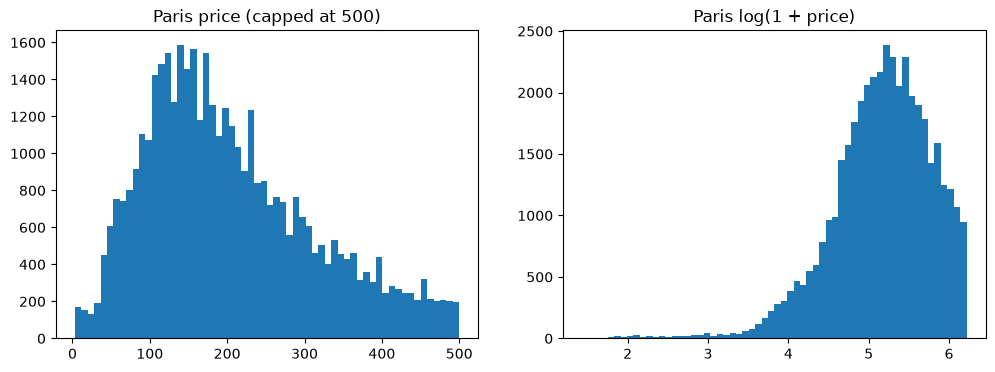

In [15]:
paris_df = prepare_city(paris)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(paris_df["price"], bins=60)
ax[0].set_title("Paris price (capped at 500)")
ax[1].hist(paris_df["log_price"], bins=60)
ax[1].set_title("Paris log(1 + price)")
plt.show()

In [16]:
res_paris, paris_splits = run_city("Paris", paris)
res_nyc, nyc_splits = run_city("NYC", nyc)
res_berlin, berlin_splits = run_city("Berlin", berlin)

all_results = pd.concat([res_nyc, res_paris, res_berlin], ignore_index=True)
test_table = all_results[all_results["split"] == "test"].drop(columns="split")
display(test_table.round(4))
display(test_table.pivot(index="model", columns="city", values="R2_log").round(3))

--- Paris ---
rows: 77679 -> 42089 after dropping missing price and capping at 500
train/val/test = 29462/8418/4209
--- NYC ---
rows: 30259 -> 19148 after dropping missing price and capping at 500
train/val/test = 13403/3830/1915
--- Berlin ---
rows: 12776 -> 8259 after dropping missing price and capping at 500
train/val/test = 5781/1652/826


,city,model,R2_log,RMSE_log,MAE_usd,RMSE_usd
2,NYC,Ridge,0.6154,0.3961,54.0671,78.2022
5,NYC,KNN,0.6645,0.3699,49.4748,72.0216
8,NYC,RandomForest,0.7672,0.3082,40.4631,60.9364
11,NYC,XGBoost,0.7830,0.2975,40.7345,60.2481
14,Paris,Ridge,0.5900,0.4000,56.8289,80.8584
17,Paris,KNN,0.6394,0.3751,54.9120,75.6920
20,Paris,RandomForest,0.7564,0.3083,46.8892,65.9308
23,Paris,XGBoost,0.7784,0.2941,44.7503,63.2487
26,Berlin,Ridge,0.8194,0.3695,37.3565,57.7133
29,Berlin,KNN,0.8049,0.3841,39.0037,58.4778


city,Berlin,NYC,Paris
model,,,
KNN,0.805,0.665,0.639
RandomForest,0.878,0.767,0.756
Ridge,0.819,0.615,0.590
XGBoost,0.892,0.783,0.778


In [17]:
display(all_results.pivot_table(index=["city", "model"], columns="split",
                                values="R2_log").round(3)[["train", "val", "test"]])

split                train    val   test
city   model                            
Berlin KNN           0.852  0.841  0.805
       RandomForest  0.981  0.884  0.878
       Ridge         0.839  0.850  0.819
       XGBoost       0.946  0.892  0.892
NYC    KNN           0.729  0.678  0.665
       RandomForest  0.969  0.777  0.767
       Ridge         0.623  0.634  0.615
       XGBoost       0.854  0.792  0.783
Paris  KNN           0.699  0.613  0.639
       RandomForest  0.965  0.730  0.756
       Ridge         0.578  0.558  0.590
       XGBoost       0.816  0.750  0.778

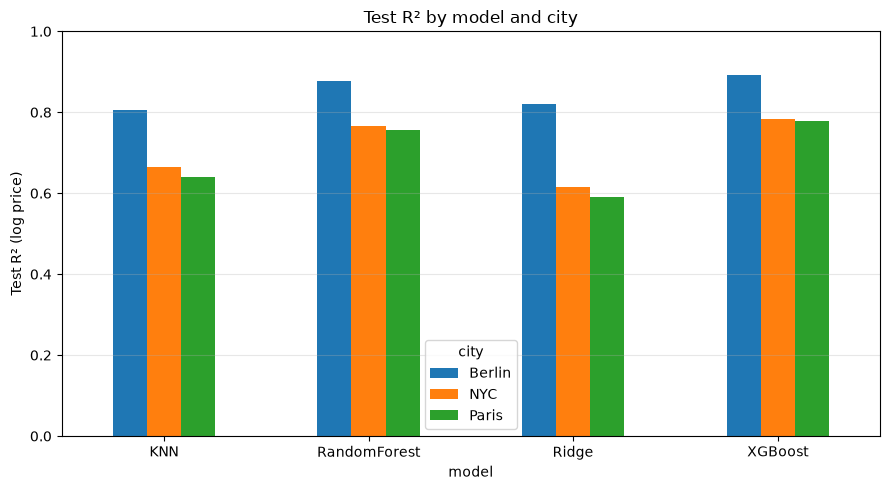

In [18]:
pivot = test_table.pivot(index="model", columns="city", values="R2_log")
pivot.plot(kind="bar", figsize=(9, 5))
plt.ylabel("Test R² (log price)")
plt.title("Test R² by model and city")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

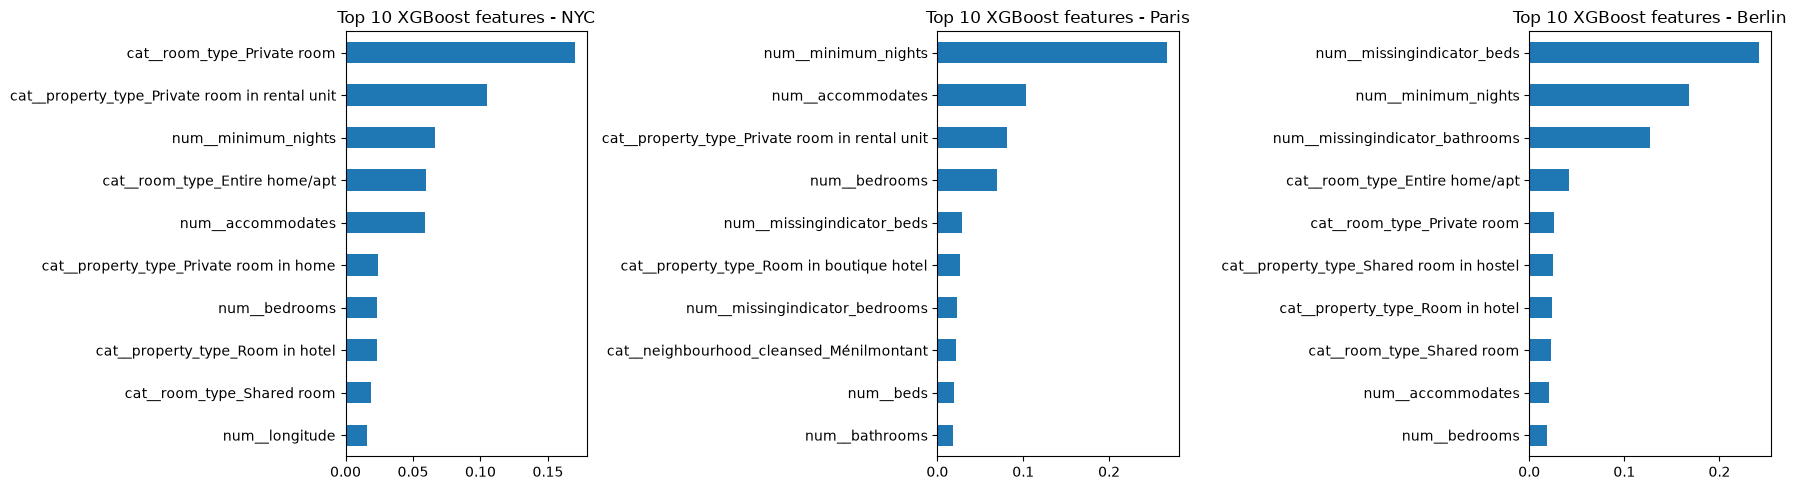

In [19]:
def xgb_importance(city_splits, top=10):
    train, val, test = city_splits
    pipe = Pipeline([("prep", build_preprocessor()),
                     ("model", get_models()["XGBoost"])])
    pipe.fit(train[NUM + CAT], train["log_price"])
    names = pipe.named_steps["prep"].get_feature_names_out()
    imp = pd.Series(pipe.named_steps["model"].feature_importances_, index=names)
    return imp.sort_values(ascending=False).head(top)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (city, splits) in zip(axes, [("NYC", nyc_splits), ("Paris", paris_splits), ("Berlin", berlin_splits)]):
    imp = xgb_importance(splits)
    imp.sort_values().plot(kind="barh", ax=ax)
    ax.set_title(f"Top 10 XGBoost features - {city}")
plt.tight_layout()
plt.show()

In [20]:
import os
os.makedirs("../data/processed", exist_ok=True)
for city, (tr, va, te) in [("nyc", nyc_splits), ("paris", paris_splits), ("berlin", berlin_splits)]:
    tr.to_pickle(f"../data/processed/{city}_train.pkl")
    va.to_pickle(f"../data/processed/{city}_val.pkl")
    te.to_pickle(f"../data/processed/{city}_test.pkl")

In [21]:
# Display all available features

print("Number of columns:", len(nyc.columns))

for i, col in enumerate(nyc.columns, start=1):
    print(f"{i}. {col}")

Number of columns: 90
1. id
2. listing_url
3. scrape_id
4. last_scraped
5. source
6. name
7. description
8. neighborhood_overview
9. picture_url
10. host_id
11. host_url
12. host_profile_id
13. host_profile_url
14. host_name
15. host_since
16. hosts_time_as_user_years
17. hosts_time_as_user_months
18. hosts_time_as_host_years
19. hosts_time_as_host_months
20. host_location
21. host_about
22. host_response_time
23. host_response_rate
24. host_acceptance_rate
25. host_is_superhost
26. host_thumbnail_url
27. host_picture_url
28. host_neighbourhood
29. host_listings_count
30. host_total_listings_count
31. host_verifications
32. host_has_profile_pic
33. host_identity_verified
34. neighbourhood
35. neighbourhood_cleansed
36. neighbourhood_group_cleansed
37. latitude
38. longitude
39. property_type
40. room_type
41. accommodates
42. bathrooms
43. bathrooms_text
44. bedrooms
45. beds
46. amenities
47. price
48. price_quote_checkin_date
49. price_quote_checkout_date
50. price_quote_total_price


In [22]:
# Preview the dataset

nyc.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,2539,https://www.airbnb.com/rooms/2539,20260614073253,2026-06-15,city scrape,11 Min to Manhattan • Prospect Park • Fast WiFi,"Bright, serene room in a renovated apartment h...",NaN,https://a0.muscache.com/pictures/hosting/Hosti...,2787,...,5.00,4.78,4.78,NaN,NaN,5,0,5,0,0.08
1,6848,https://www.airbnb.com/rooms/6848,20260614073253,2026-06-14,city scrape,Only 2 stops to Manhattan studio,Comfortable studio apartment with super comfor...,NaN,https://a0.muscache.com/pictures/e4f031a7-f146...,15991,...,4.80,4.69,4.59,NaN,NaN,1,1,0,0,0.95
2,6872,https://www.airbnb.com/rooms/6872,20260614073253,2026-06-14,city scrape,Uptown Sanctuary w/ Private Bath (Month to Month),This charming distancing-friendly month-to-mon...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,16104,...,5.00,5.00,5.00,NaN,NaN,2,0,2,0,0.04
3,6990,https://www.airbnb.com/rooms/6990,20260614073253,2026-06-14,city scrape,UES Beautiful Blue Room,Beautiful peaceful healthy home,NaN,https://a0.muscache.com/pictures/45fb4ec7-6856...,16800,...,4.94,4.85,4.84,NaN,NaN,1,0,1,0,1.24
4,7097,https://www.airbnb.com/rooms/7097,20260614073253,2026-06-14,city scrape,"Perfect for Your Parents, With Garden & Patio",Parents/grandparents coming to town or are you...,NaN,https://a0.muscache.com/pictures/aaac19fc-4b4d...,17571,...,4.93,4.95,4.82,NaN,NaN,2,0,2,0,2.12


In [23]:
# Check the target variable

print("NYC price datatype:", nyc["price"].dtype)
print("Sample prices:")
print(nyc["price"].head(10))

NYC price datatype: str
Sample prices:
0    $113.97
1    $117.27
2     $80.06
3     $77.17
4    $202.47
5    $365.97
6    $154.87
7     $91.07
8        NaN
9        NaN
Name: price, dtype: str


In [24]:
# Clean the price column

nyc["price"] = (
    nyc["price"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
)

nyc["price"] = pd.to_numeric(nyc["price"], errors="coerce")

print("NYC price datatype:", nyc["price"].dtype)
print("Missing prices:", nyc["price"].isna().sum())
print("Sample cleaned prices:")
print(nyc["price"].head(10))
nyc["price_clean"] = nyc["price"]

NYC price datatype: float64
Missing prices: 8744
Sample cleaned prices:
0    113.97
1    117.27
2     80.06
3     77.17
4    202.47
5    365.97
6    154.87
7     91.07
8       NaN
9       NaN
Name: price, dtype: float64


In [25]:
# Check missing values

print("Missing values in important columns:")
print(nyc[["price", "minimum_nights", "number_of_reviews",
           "reviews_per_month", "availability_365"]].isna().sum())

Missing values in important columns:
price                8744
minimum_nights          2
number_of_reviews       0
reviews_per_month    8559
availability_365        0
dtype: int64


In [26]:
# Find price-related columns

price_cols = [col for col in nyc.columns if "price" in col.lower()]

print("Price-related columns:")
for col in price_cols:
    print(col)

Price-related columns:
price
price_quote_checkin_date
price_quote_checkout_date
price_quote_total_price
price_quote_price_per_night
price_quote_raw
price_clean


In [27]:
# Inspect price-related columns

price_cols = [
    "price",
    "price_quote_checkin_date",
    "price_quote_checkout_date",
    "price_quote_total_price",
    "price_quote_price_per_night",
    "price_quote_raw"
]

nyc[price_cols].head(10)

,price,price_quote_checkin_date,price_quote_checkout_date,price_quote_total_price,price_quote_price_per_night,price_quote_raw
0,113.97,2026-07-11,2026-08-10,3419.19,113.97,"{""quote"": {""taxes"": null, ""currency"": ""USD"", ""..."
1,117.27,2026-12-20,2027-01-19,3518.00,117.27,"{""quote"": {""taxes"": null, ""currency"": ""USD"", ""..."
2,80.06,2026-09-01,2026-10-01,2401.84,80.06,"{""quote"": {""taxes"": null, ""currency"": ""USD"", ""..."
3,77.17,2026-12-06,2027-01-05,2315.00,77.17,"{""quote"": {""taxes"": null, ""currency"": ""USD"", ""..."
4,202.47,2027-02-28,2027-03-30,6074.17,202.47,"{""quote"": {""taxes"": null, ""currency"": ""USD"", ""..."
5,365.97,2027-01-02,2027-02-01,10979.00,365.97,"{""quote"": {""taxes"": null, ""currency"": ""USD"", ""..."
6,154.87,2026-07-01,2026-07-31,4646.00,154.87,"{""quote"": {""taxes"": null, ""currency"": ""USD"", ""..."
7,91.07,2026-07-01,2026-07-31,2731.98,91.07,"{""quote"": {""taxes"": null, ""currency"": ""USD"", ""..."
8,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN


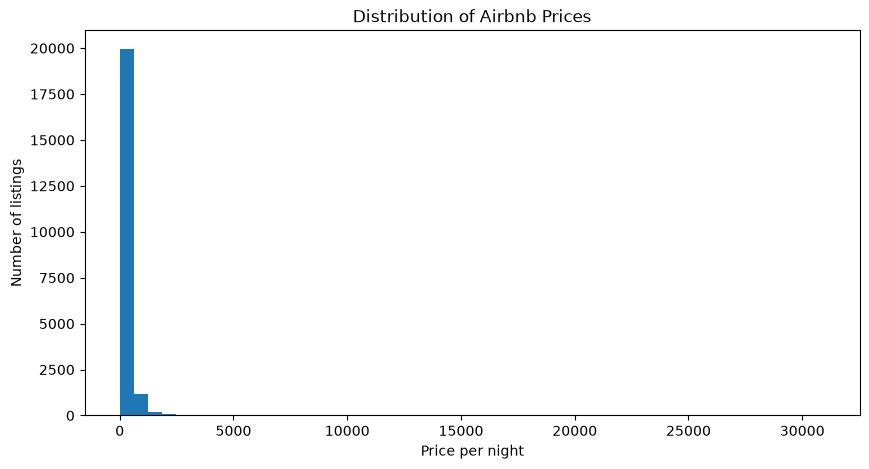

In [28]:
# Check price distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(nyc["price_clean"].dropna(), bins=50)
plt.xlabel("Price per night")
plt.ylabel("Number of listings")
plt.title("Distribution of Airbnb Prices")
plt.show()

In [29]:
# Check price outliers using IQR

q1 = nyc["price_clean"].quantile(0.25)
q3 = nyc["price_clean"].quantile(0.75)

iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

outliers = nyc[
    (nyc["price_clean"] < lower_bound) |
    (nyc["price_clean"] > upper_bound)
]

print("Number of outliers:", len(outliers))
print("Percentage of outliers:", round(len(outliers) / nyc["price_clean"].notna().sum() * 100, 2), "%")

Q1: 96.875
Q3: 302.72
IQR: 205.84500000000003
Lower bound: -211.89250000000004
Upper bound: 611.4875000000001
Number of outliers: 1608
Percentage of outliers: 7.47 %


In [30]:
# Inspect the most expensive listings

print(nyc["price_clean"].nlargest(20).to_list())

[30972.96, 14864.0, 14864.0, 12279.07, 12078.47, 11061.8, 11061.8, 10986.0, 10986.0, 10986.0, 10986.0, 10944.83, 10000.0, 10000.0, 10000.0, 9690.48, 9532.76, 9439.38, 9107.53, 8296.33]


In [31]:
# Inspect listings with very high prices

high_price = nyc[nyc["price_clean"] > 5000]

print("Listings above $5,000:", len(high_price))

high_price[
    ["id", "name", "room_type", "price_clean",
     "minimum_nights", "maximum_nights",
     "number_of_reviews", "availability_365"]
].head(20)

Listings above $5,000: 38


,id,name,room_type,price_clean,minimum_nights,maximum_nights,number_of_reviews,availability_365
731,1623431,Enormous Chrysler-View Bedroom/Bath,Private room,12078.47,30.0,180.0,1,83
798,990529,Sunny Luxury Bedroom Guest Bathroom,Private room,12279.07,30.0,180.0,3,83
4698,15345019,NYC Firehouse-Greenpoint BRKLYN,Private room,8171.32,31.0,1125.0,29,358
8268,34368310,NEW ! Chic Designer Blue,Private room,9690.48,30.0,45.0,261,263
9352,39553889,"Paper Factory, Executive King",Private room,10000.00,1.0,1125.0,3,365
9353,39554366,"Paper Factory, Superior Room w/ Double Beds",Private room,10000.00,1.0,1125.0,13,365
9354,39554839,"Paper Factory, Deluxe King",Private room,10000.00,1.0,1125.0,2,365
12280,49920227,WELCOME HOME 15 MINUTES TO MANHATTAN BOOK TODAY,Private room,10944.83,30.0,1125.0,10,365
12912,52862058,Lux Studio on Wall Street. Heart of Fidi!,Entire home/apt,8296.33,30.0,1125.0,1,83
16172,730322098122161810,St. Regis Residence Club - 2 BR Suite. 5th Ave...,Private room,5706.00,2.0,7.0,1,31


In [32]:
import pandas as pd

paris_path = "../data/Paris/listings (1).csv.gz"

paris = pd.read_csv(paris_path)

print("Paris dataset shape:", paris.shape)

print("\nFirst 5 rows:")
display(paris.head())

print("\nColumns:")
print(paris.columns.tolist())

print("\nData types:")
print(paris.dtypes)

Paris dataset shape: (77679, 90)

First 5 rows:


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,114543,https://www.airbnb.com/rooms/114543,20260616211535,2026-06-21,city scrape,Charming 55m² flat - Eiffel Tower,Fully furnished charming flat with lots of spa...,NaN,https://a0.muscache.com/pictures/airflow/Hosti...,581233,...,4.97,4.93,4.77,7511502831082,NaN,1,1,0,0,0.83
1,115107,https://www.airbnb.com/rooms/115107,20260616211535,2026-06-25,previous scrape,Charming two-bed apartment with balcony,This charming 60 square meter apartment is per...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,379042,...,5.00,4.40,4.40,7511002008206,NaN,2,1,1,0,0.22
2,115655,https://www.airbnb.com/rooms/115655,20260616211535,2026-06-20,city scrape,Family loft with a private courtyard,"Beautiful openplan loft situated in a private,...",NaN,https://a0.muscache.com/pictures/33160696/6171...,584977,...,4.69,4.04,4.40,7511805457226,NaN,1,1,0,0,1.24
3,120494,https://www.airbnb.com/rooms/120494,20260616211535,2026-06-19,city scrape,Romantic Hideout in Paris,"""As full of spirit as the month of May, as gor...",NaN,https://a0.muscache.com/pictures/833324/f66a6b...,606427,...,4.97,4.85,4.75,7511300905786,NaN,1,1,0,0,2.03
4,125686,https://www.airbnb.com/rooms/125686,20260616211535,2026-06-20,city scrape,Studio - République/Canal Saint Martin,"Tiny studio in central Paris, between the Mara...",NaN,https://a0.muscache.com/pictures/2704337/e28df...,624523,...,4.92,4.87,4.69,"Available with a mobility lease only (""bail mo...",NaN,1,1,0,0,0.79



Columns:
['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url', 'host_profile_id', 'host_profile_url', 'host_name', 'host_since', 'hosts_time_as_user_years', 'hosts_time_as_user_months', 'hosts_time_as_host_years', 'hosts_time_as_host_months', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'price_quote_checkin_date', 'price_quote_checkout_date', 'price_quote_total_price', 'price_quote_price_per_night', 'price_quote_raw', 'm

In [33]:


print("Columns containing 'price':")
print([col for col in paris.columns if "price" in col.lower()])

print("\nPrice-related information:")
for col in paris.columns:
    if "price" in col.lower():
        print(f"\n--- {col} ---")
        print(paris[col].head())
        print("Missing:", paris[col].isna().sum())

Columns containing 'price':
['price', 'price_quote_checkin_date', 'price_quote_checkout_date', 'price_quote_total_price', 'price_quote_price_per_night', 'price_quote_raw']

Price-related information:

--- price ---
0    $226.75
1        NaN
2    $225.00
3     $95.33
4     $37.40
Name: price, dtype: str
Missing: 29277

--- price_quote_checkin_date ---
0    2026-06-27
1           NaN
2    2026-06-24
3    2026-07-18
4    2026-08-05
Name: price_quote_checkin_date, dtype: str
Missing: 25869

--- price_quote_checkout_date ---
0    2026-07-01
1           NaN
2    2026-06-25
3    2026-07-21
4    2026-09-04
Name: price_quote_checkout_date, dtype: str
Missing: 25869

--- price_quote_total_price ---
0     907.0
1       NaN
2     225.0
3     286.0
4    1122.0
Name: price_quote_total_price, dtype: float64
Missing: 29277

--- price_quote_price_per_night ---
0    226.75
1       NaN
2    225.00
3     95.33
4     37.40
Name: price_quote_price_per_night, dtype: float64
Missing: 29277

--- price_quote_ra

Missing price values: 29277

Paris price statistics:
count    48402.000000
mean       321.230271
std        832.551387
min          3.200000
25%        131.330000
50%        205.500000
75%        342.000000
max      97003.050000
Name: price_clean, dtype: float64


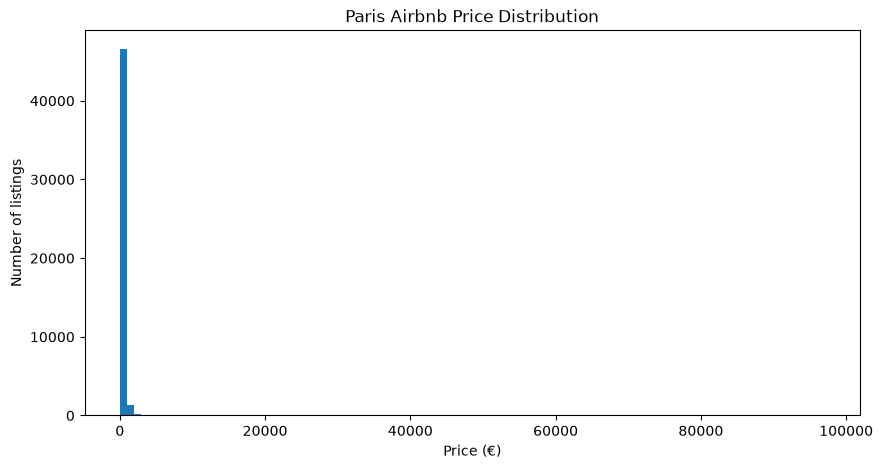

In [34]:


import numpy as np
import matplotlib.pyplot as plt

# Convert "$226.75" -> 226.75
paris["price_clean"] = (
    paris["price"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .replace("nan", np.nan)
    .astype(float)
)

print("Missing price values:", paris["price_clean"].isna().sum())

print("\nParis price statistics:")
print(paris["price_clean"].describe())

# Histogram
plt.figure(figsize=(10, 5))
plt.hist(paris["price_clean"].dropna(), bins=100)
plt.xlabel("Price (€)")
plt.ylabel("Number of listings")
plt.title("Paris Airbnb Price Distribution")
plt.show()


In [35]:
Q1 = paris["price_clean"].quantile(0.25)
Q3 = paris["price_clean"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = paris[
    (paris["price_clean"] < lower_bound) |
    (paris["price_clean"] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Number of outliers:", len(outliers))
print("Percentage of outliers:", len(outliers) / paris["price_clean"].notna().sum() * 100)

print("\nHighest 10 prices:")
print(
    paris["price_clean"]
    .dropna()
    .sort_values(ascending=False)
    .head(10)
)

Q1: 131.33
Q3: 342.0
IQR: 210.67
Lower bound: -184.67499999999998
Upper bound: 658.005
Number of outliers: 3799
Percentage of outliers: 7.8488492211065655

Highest 10 prices:
46967    97003.05
53054    70080.00
28834    57064.00
5371     34240.00
51626    24949.00
44209    22500.00
57875    20132.00
44210    20000.00
51046    19380.00
54987    17255.80
Name: price_clean, dtype: float64


In [36]:
berlin_path = "../data/berlin/listings (2).csv.gz"
berlin = pd.read_csv(berlin_path)

print("Berlin dataset shape:", berlin.shape)
print("\nFirst 5 rows:")
display(berlin.head())

print("\nColumns:")
print(berlin.columns.tolist())

Berlin dataset shape: (12776, 90)

First 5 rows:


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,3176,https://www.airbnb.com/rooms/3176,20260626225638,2026-07-03,previous scrape,Fabulous Flat in great Location,This beautiful first floor apartment is situa...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,3718,...,4.70,4.92,4.61,First name and Last name: Nicolas Krotz <br/> ...,NaN,1,1,0,0,0.72
1,9991,https://www.airbnb.com/rooms/9991,20260626225638,2026-06-27,city scrape,Geourgeous flat - outstanding views,4 bedroom with very large windows and outstand...,NaN,https://a0.muscache.com/pictures/42799131/59c8...,33852,...,5.00,4.86,4.86,03/Z/RA/003410-18,NaN,1,1,0,0,0.05
2,14325,https://www.airbnb.com/rooms/14325,20260626225638,2026-07-03,previous scrape,Studio Apartment in Prenzlauer Berg,The apartment is located on the upper second f...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,55531,...,4.85,4.60,4.45,NaN,NaN,2,2,0,0,0.13
3,17904,https://www.airbnb.com/rooms/17904,20260626225638,2026-07-03,previous scrape,Beautiful Kreuzberg studio - 3 months minimum,- bright studio with scenic view on a river - ...,NaN,https://a0.muscache.com/pictures/d9a6f8be-54b9...,68997,...,4.92,4.88,4.65,NaN,NaN,1,1,0,0,1.49
4,20858,https://www.airbnb.com/rooms/20858,20260626225638,2026-06-27,city scrape,Designer Loft in Berlin Mitte,Bright and sunny condo with two balconies in a...,NaN,https://a0.muscache.com/pictures/108232/205b19...,71331,...,4.55,4.92,4.40,03/Z/RA/009767-24,NaN,1,1,0,0,0.87



Columns:
['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url', 'host_profile_id', 'host_profile_url', 'host_name', 'host_since', 'hosts_time_as_user_years', 'hosts_time_as_user_months', 'hosts_time_as_host_years', 'hosts_time_as_host_months', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'price_quote_checkin_date', 'price_quote_checkout_date', 'price_quote_total_price', 'price_quote_price_per_night', 'price_quote_raw', 'm

In [37]:
print(berlin["price"].head(10))
print("\nMissing price values:", berlin["price"].isna().sum())
print("\nPrice data type:", berlin["price"].dtype)

0    $160.71
1    $193.33
2        NaN
3     $10.88
4    $372.67
5     $16.86
6    $243.50
7        NaN
8    $212.50
9        NaN
Name: price, dtype: str

Missing price values: 4335

Price data type: str


In [38]:
import numpy as np

berlin["price_clean"] = (
    berlin["price"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .replace("nan", np.nan)
    .astype(float)
)

print("Missing price values:", berlin["price_clean"].isna().sum())
print("\nBerlin price statistics:")
print(berlin["price_clean"].describe())

Missing price values: 4335

Berlin price statistics:
count     8441.000000
mean       160.729973
std        204.998115
min          2.720000
25%         72.000000
50%        130.670000
75%        207.000000
max      10025.000000
Name: price_clean, dtype: float64


In [39]:
q1 = berlin["price_clean"].quantile(0.25)
q3 = berlin["price_clean"].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = berlin[
    (berlin["price_clean"] < lower_bound) |
    (berlin["price_clean"] > upper_bound)
]

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Number of outliers:", len(outliers))
print("Outlier percentage:", len(outliers) / berlin["price_clean"].notna().sum() * 100)

print("\nHighest prices:")
print(berlin["price_clean"].dropna().sort_values(ascending=False).head(10).to_list())

Q1: 72.0
Q3: 207.0
IQR: 135.0
Lower bound: -130.5
Upper bound: 409.5
Number of outliers: 362
Outlier percentage: 4.288591399123327

Highest prices:
[10025.0, 7999.2, 4458.0, 2956.0, 2296.0, 2270.4, 2269.0, 2100.0, 2033.33, 1825.0]


# Final Analysis and Conclusion

## Method
Listings with a missing price were removed and nightly price was capped at $500 to limit extreme outliers. Models were trained on log(1 + price) with a 7:2:1 train/validation/test split, using the same features and preprocessing (median imputation with missing-value flags, scaling, one-hot encoding) for every city. Four models were compared on NYC (19,148 listings), Paris (42,089) and Berlin (8,259): Ridge, KNN, Random Forest and XGBoost.

## Results (test R² on log price)
| Model | NYC | Paris | Berlin |
|---|---|---|---|
| Ridge | 0.615 | 0.590 | 0.819 |
| KNN | 0.665 | 0.639 | 0.805 |
| Random Forest | 0.767 | 0.756 | 0.878 |
| XGBoost | 0.783 | 0.778 | 0.892 |

## Findings
- XGBoost performed best in all three cities, followed by Random Forest. Tree ensembles clearly outperform Ridge and KNN, which suggests non-linear relationships between listing features and price.
- Handling outliers (price cap + log transform) was the largest single improvement. Earlier runs on raw price gave R² below 0.2 for NYC and negative R² for Paris and Berlin tree models.
- Random Forest overfits more than XGBoost (train R² about 0.97 vs test about 0.77 on NYC).
- Berlin scores highest in every model, and its validation and test scores agree, so this is not a lucky split. A likely reason is a more homogeneous market, but this was not tested.

## Limitations
- R² is computed on log price, so it is not directly comparable to dollar-scale metrics or to the paper's numbers (different data snapshot and columns).
- Paris prices carry a "$" sign although the quote data suggests EUR; the currency was not verified.
- Text, amenity and date features, and the neural network, are not included in this notebook.
